In [ ]:
# !pip install -q -U transformers trl datasets num2words bitsandbytes peft accelerate "pillow<12.0"

import torch
from datasets import Dataset
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

print("1. Loading processor and 4-bit model...")
model_id = "HuggingFaceTB/SmolVLM2-500M-Instruct"

processor = AutoProcessor.from_pretrained(model_id)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)
model = prepare_model_for_kbit_training(model)

print("2. Setting up LoRA adapters...")
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)

print("3. Generating Agentic Training Data...")
dummy_image_milk = Image.new('RGB', (224, 224), color = (255, 255, 255))
dummy_image_eggs = Image.new('RGB', (224, 224), color = (250, 235, 215))

agent_data = {
    "image": [dummy_image_milk, dummy_image_eggs],
    "action_observed": ["User took out milk, carton is 10% full", "User removed last egg from carton"],
    "tool_output": [
        '{"name": "add_to_grocery_list", "arguments": {"item": "whole milk", "urgency": "high"}}',
        '{"name": "add_to_grocery_list", "arguments": {"item": "eggs (12 pack)", "urgency": "high"}}'
    ]
}
dataset = Dataset.from_dict(agent_data)

def format_agent_dataset(example):
    tools_definition = """
    TOOLS AVAILABLE:
    1. add_to_grocery_list(item: str, urgency: str)
    2. log_inventory(item: str, quantity: float)
    """
    user_prompt = f"{tools_definition}\nAnalyze the user's action and trigger the correct tool."
    assistant_response = f"Observation: {example['action_observed']}. Tool Call: {example['tool_output']}"

    messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": user_prompt}]},
        {"role": "assistant", "content": [{"type": "text", "text": assistant_response}]}
    ]

    text = processor.apply_chat_template(messages, tokenize=False)
    return {"text": text, "images": example["image"]}

formatted_dataset = dataset.map(format_agent_dataset, remove_columns=dataset.column_names)

def collate_fn(examples):
    texts = [example["text"] for example in examples]
    images = [[example["images"]] for example in examples]

    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # Keep the input caster just to be safe
    for k, v in batch.items():
        if torch.is_floating_point(v):
            batch[k] = v.to(torch.float16)

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    return batch

print("4. Launching Agentic Training...")
training_args = SFTConfig(
    output_dir="./agentic-pantry-vlm",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    max_steps=100,
    # ==========================================
    # THE NUCLEAR FIX: Turn off mixed precision
    # This disables the grad_scaler completely
    # ==========================================
    fp16=False,
    bf16=False,
    optim="paged_adamw_8bit",
    dataset_text_field="text",
    remove_unused_columns=False,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted_dataset,
    data_collator=collate_fn,
    processing_class=processor,
)

trainer.train()
print("Training Complete! The Pantry Robot is ready.")

1. Loading processor and 4-bit model...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

2. Setting up LoRA adapters...
3. Generating Agentic Training Data...


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.


4. Launching Agentic Training...


Step,Training Loss
10,9.080244
20,0.661823
30,0.296263
40,0.245192
50,0.213437
60,0.192827
70,0.177608
80,0.165514
90,0.156634
100,0.152365


Training Complete! The Pantry Robot is ready.


In [ ]:
import json
import torch
from PIL import Image

# ==========================================
# 1. THE BACKEND (Your actual Python Tools)
# ==========================================
def add_to_grocery_list(item, urgency):
    print(f"\n✅ [API SUCCESS] Added '{item}' to the Todoist Grocery List with {urgency.upper()} priority!")
    return True

def log_inventory(item, quantity):
    print(f"\n📊 [API SUCCESS] Logged {quantity} units of '{item}' into the fridge database.")
    return True

# Map the string names the AI generates to the actual Python functions
available_functions = {
    "add_to_grocery_list": add_to_grocery_list,
    "log_inventory": log_inventory
}

# ==========================================
# 2. THE TEST SCENARIO
# ==========================================
# We use the dummy white image (representing milk) and give it a new observation
test_image = Image.new('RGB', (224, 224), color = (255, 255, 255))
action_text = "User shook the milk carton, it sounds completely empty."

tools_definition = """
TOOLS AVAILABLE:
1. add_to_grocery_list(item: str, urgency: str)
2. log_inventory(item: str, quantity: float)

EXAMPLE PREVIOUS INTERACTION:
Observation: User removed last egg from carton.
Tool Call: {"name": "add_to_grocery_list", "arguments": {"item": "eggs (12 pack)", "urgency": "high"}}
"""

# Force the model to complete the pattern we taught it
user_prompt = f"{tools_definition}\nAnalyze the user's action and trigger the correct tool.\nObservation: {action_text}. Tool Call:"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt}
        ]
    }
]
# ==========================================
# 3. RUNNING THE AI (Forced JSON Mode)
# ==========================================
print("🧠 The Pantry Robot is watching the camera...")

model.eval()
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()
model.config.use_cache = True

# 1. We make the prompt aggressively demand JSON
user_prompt = f"{tools_definition}\nObservation: {action_text}\nCRITICAL INSTRUCTION: You must output ONLY valid JSON. Do not write any conversational text.\nTool Call:"

messages = [
    {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": user_prompt}]}
]

text_prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)

# 2. THE JEDI MIND TRICK: We start the Assistant's response for it!
text_prompt += '{"name": "'

inputs = processor(text=text_prompt, images=[test_image], return_tensors="pt").to("cuda")

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False
    )

# Extract the new tokens
generated_text = processor.batch_decode(
    generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
)[0].strip()

# Re-attach the opening brackets we forced
full_json_output = '{"name": "' + generated_text
print(f"🤖 Raw AI Output: {full_json_output}")

# ==========================================
# 4. THE PARSER & EXECUTOR
# ==========================================
print("⚙️  Parsing the JSON and triggering the API...")

# Clean up any trailing junk text the AI might add after the JSON closes
if "}" in full_json_output:
    full_json_output = full_json_output[:full_json_output.rfind("}")+1]

try:
    tool_call = json.loads(full_json_output)

    func_name = tool_call.get("name")
    args = tool_call.get("arguments", {})

    if func_name in available_functions:
        available_functions[func_name](**args)
    else:
        print(f"❌ Error: AI hallucinated an unknown tool: {func_name}")

except json.JSONDecodeError:
    print("❌ Error: AI still failed the JSON. (Hint: It needs more training steps!)")

🧠 The Pantry Robot is watching the camera...
🤖 Raw AI Output: {"name": "add_to_grocery_list", "arguments": {"item": "milk (12 pack)", "urgency": "low"}}
⚙️  Parsing the JSON and triggering the API...

✅ [API SUCCESS] Added 'milk (12 pack)' to the Todoist Grocery List with LOW priority!


📸 Please upload a photo of your food or fridge:


Saving refrigerator-full-healthy-food-24502134.webp to refrigerator-full-healthy-food-24502134.webp

✅ Successfully loaded: refrigerator-full-healthy-food-24502134.webp


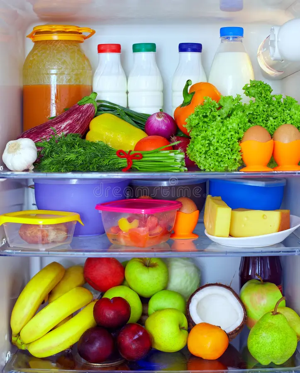

--------------------------------------------------
What action did you take with this item? (e.g., 'I took the last egg', 'I put this back empty'): "I ate the last yellow banana from the bottom drawer."

🧠 The Pantry Robot is analyzing the image...
🤖 Raw AI Output: {"name": "add_to_grocery_list", "arguments": {"item": "bananas (12 pack)", "urgency": "high"}}

⚙️  Executing...

✅ [API SUCCESS] Added 'bananas (12 pack)' to the Todoist Grocery List with HIGH priority!


In [ ]:
from google.colab import files
from PIL import Image
import io
import json
import torch

# 1. THE FILE UPLOAD WIDGET
print("📸 Please upload a photo of your food or fridge:")
uploaded = files.upload()

# Grab the file name of the uploaded image
filename = list(uploaded.keys())[0]
real_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

print(f"\n✅ Successfully loaded: {filename}")
# Show a quick preview of the image in the notebook (resized so it doesn't take up the whole screen)
display(real_image.resize((300, int(300 * real_image.height / real_image.width))))

# 2. GET THE USER'S OBSERVATION
# This will create a text box asking you what is happening in the photo
print("-" * 50)
action_text = input("What action did you take with this item? (e.g., 'I took the last egg', 'I put this back empty'): ")

# 3. SETTING UP THE AI
tools_definition = """
TOOLS AVAILABLE:
1. add_to_grocery_list(item: str, urgency: str)
2. log_inventory(item: str, quantity: float)

EXAMPLE PREVIOUS INTERACTION:
Observation: User removed last egg from carton.
Tool Call: {"name": "add_to_grocery_list", "arguments": {"item": "eggs (12 pack)", "urgency": "high"}}
"""

user_prompt = f"{tools_definition}\nObservation: {action_text}\nCRITICAL INSTRUCTION: You must output ONLY valid JSON. Do not write any conversational text.\nTool Call:"

messages = [
    {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": user_prompt}]}
]

# 4. RUNNING THE MODEL
print("\n🧠 The Pantry Robot is analyzing the image...")
model.eval()
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()
model.config.use_cache = True

text_prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
text_prompt += '{"name": "' # The Jedi Mind Trick

inputs = processor(text=text_prompt, images=[real_image], return_tensors="pt").to("cuda")

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False
    )

generated_text = processor.batch_decode(
    generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
)[0].strip()

full_json_output = '{"name": "' + generated_text

# Clean up trailing text
if "}" in full_json_output:
    full_json_output = full_json_output[:full_json_output.rfind("}")+1]

print(f"🤖 Raw AI Output: {full_json_output}")

# 5. TRIGGERING THE API
print("\n⚙️  Executing...")
try:
    tool_call = json.loads(full_json_output)
    func_name = tool_call.get("name")
    args = tool_call.get("arguments", {})

    if func_name in available_functions:
        available_functions[func_name](**args)
    else:
        print(f"❌ Error: AI hallucinated an unknown tool: {func_name}")

except json.JSONDecodeError:
    print("❌ Error: AI failed the JSON format.")

In [ ]:
from google.colab import drive
import os

# 1. Ask for permission to connect to your Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Create a dedicated folder in your Drive for the model
save_path = "/content/drive/MyDrive/PantryRobot-VLM"
os.makedirs(save_path, exist_ok=True)

# 3. Save the trained LoRA weights and the Vision Processor
print(f"Saving the Pantry Robot to: {save_path}")
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print("✅ SUCCESS! Your Pantry Robot is permanently saved to your Google Drive.")


Mounting Google Drive...
Mounted at /content/drive
Saving the Pantry Robot to: /content/drive/MyDrive/PantryRobot-VLM
✅ SUCCESS! Your Pantry Robot is permanently saved to your Google Drive.
